## Example network creation using PoresPy

Author: Masa Prodanovic


In [101]:
import numpy as np

# change the name of the file as desired
# There are two options - Berea200.txt and Berea500.txt. They are both representing the same micromodel, but are acting as two different resolutions.
filename = 'Berea200.txt'
N = 200 #linear size, 200 or 500

def read_text_file(filename,datatype):
    test=open(filename, 'r')
    data=np.fromfile(test,dtype=datatype,count=-1,sep=" ")
    test.close()
    return data

     
berea = read_text_file(filename,'float')
data=np.transpose(berea).reshape(N,N)


__snow2__


This newer version of the original SNOW algorithm creates network (that can be used in openpnm simulation)
It further has additional features such as:
- processing multiple phases (and creating dual networks), something relevant to batteries
- adding boundary pores (this can be useful in simulation)
- parallelization for large images

More on: https://porespy.org/examples/networks/reference/snow2.html

## Disk pack example
Lots of the following is copied from porespy documentation
https://porespy.org/examples/networks/reference/snow2.html

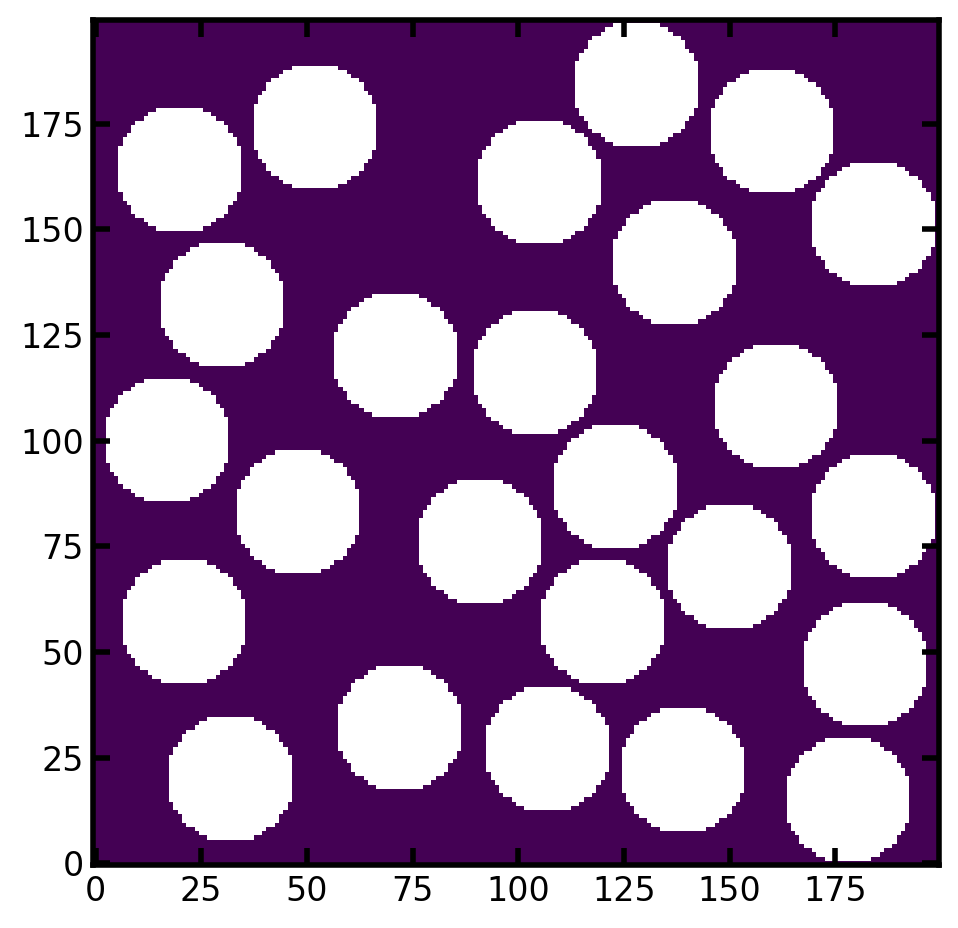

In [102]:
import porespy as ps
import numpy as np

im = ~ps.generators.random_spheres([200, 200], r=15, clearance=5)
ps.imshow(im);

One of the main features of snow2 is the ability to extract networks from multiple phases simultaneously, and have them be interconnected. This is quite useful for modeling electrochemial devices for instance, since transport occurs in the solid and void phases simultaneously, and the processes are coupled. For a powerful example, see Khan et al. where the transient discharage of a Li-ion battery was modelled using PNMs. Li-ion batteries contain 3 distinct phases: liquid electrolyte, solid active material, and carbonaceous binder.

Note that snow2 does not need to operate on mulitphase phases, only that it can if needed. It accomplishes this flexibility by ignoring all 0’s in the input images, and treating all voxels with values of 1, 2, 3, etc. as distinct phases. Therefore supplying an image of 0’s and 1’s will result in a standard single phase extraction, while supplying an image of 1’s and 2’s will create a dual phase network.

A few additional notes:

    It should also be mentioned that the image can contain 0’s as well as values (ie. 1, 2, 3), so can have multiple phases and have some regions ignored

    The voxels values do not have be integers or sequential. Each unique numerical value in the image is treated as phase.

Let’s explore this:

In [103]:
# standard extraction from an image of 0s and 1s
net1 = ps.networks.snow2(phases=im, boundary_width=0)
# dual network extraction from an image of 1s and 2s
net2 = ps.networks.snow2(phases=im.astype(int) + 1, boundary_width=0)

# If you want to give phases names, this is what is supposed to be done (otherwise they will just be numbered
#net2 = ps.networks.snow2(phases=im.astype(int) + 1, phase_alias={1: 'solid', 2: 'void'}, boundary_width=0)

The “object” returned by the snow2 function is a dataclass-like object, meaning it has data attached to it as attributes. These attributes are the segmented image called regions, the OpenPNM compatible network called network, and a copy of the input image called phases which will be padded to be the same size as regions if any boundaries were added.

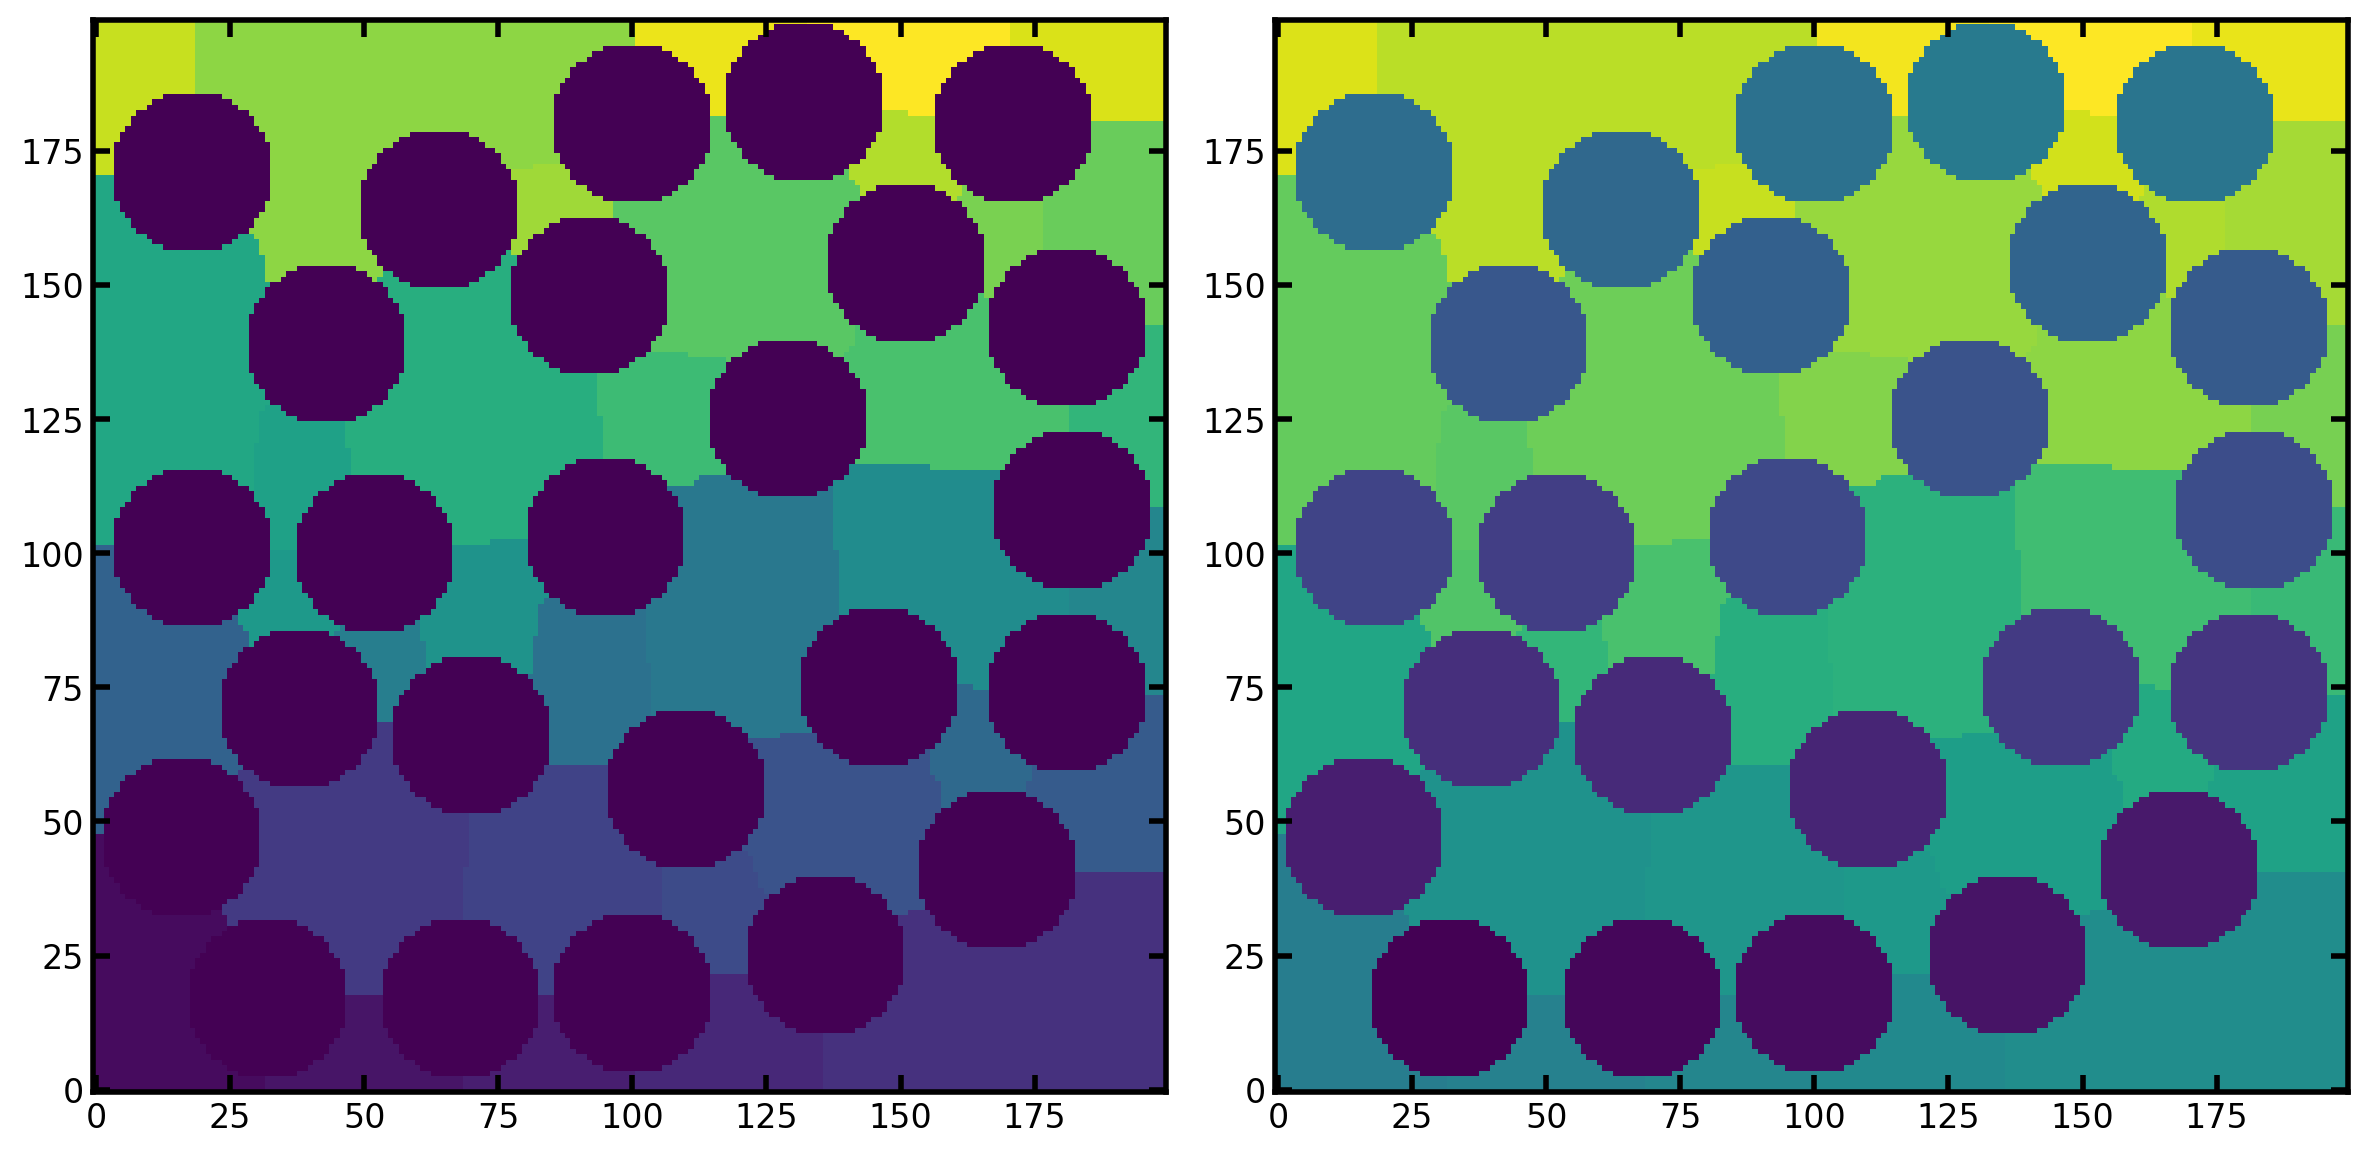

In [56]:
fig, ax = plt.subplots(1, 2, figsize=[12, 6])
ax[0].imshow(net1.regions, origin='lower', interpolation='none')
ax[1].imshow(net2.regions, origin='lower', interpolation='none');

On the left we can see that the spherical particles are all purple, which indicates 0, because they have not been labelled by the function. On the right the particles each have a unique greyscale value because they have been labelled as distinct regions.

The returned objects (net1 and net2) also contain the pore networks, in OpenPNM format. We can overlay these networks with the above images. Let’s start with the single phase network, colored in red:

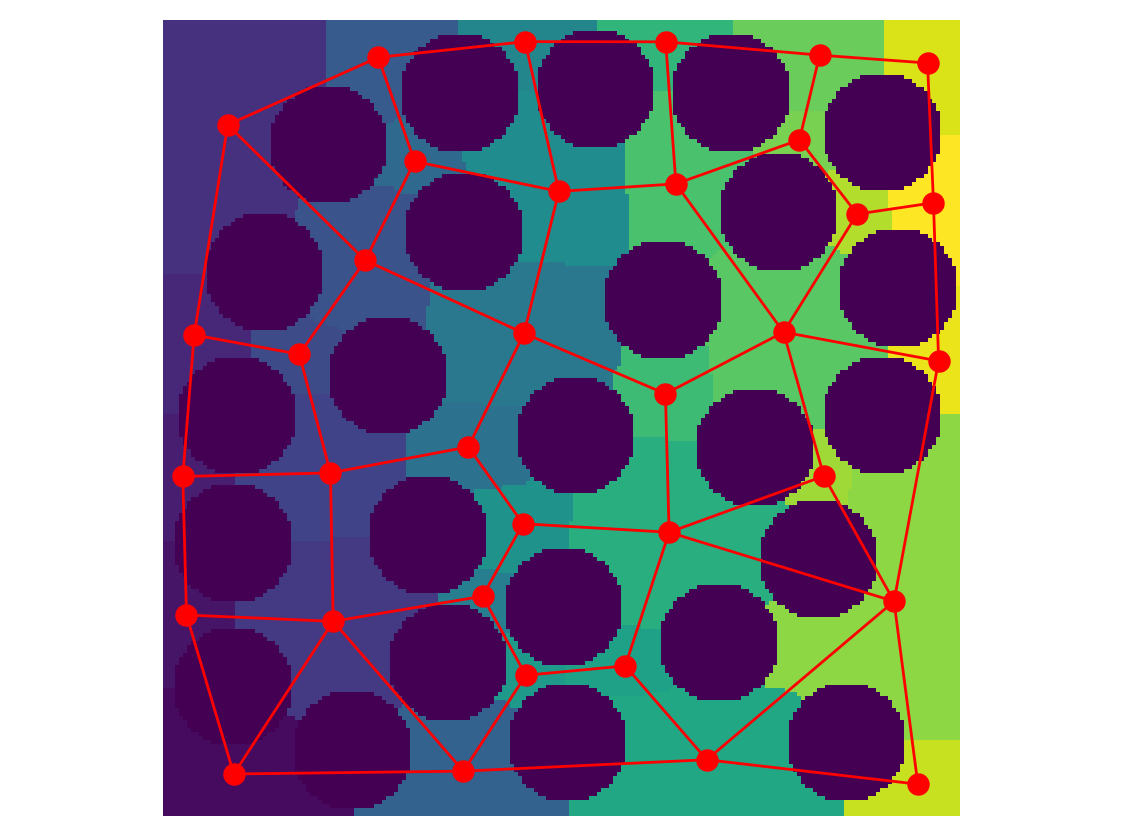

In [66]:
# create and visualize network in phase 0 of the original
pn1 = op.io.network_from_porespy(net1.network)

ax = op.visualization.plot_connections(pn1, c='r') #throat connections plot as red lines
ax = op.visualization.plot_coordinates(pn1, c='r',markersize=50, ax=ax) #pore throat centers marked wi
fig, ax = plt.gcf(), plt.gca()
ax.imshow(net1.regions.T)
ax.axis(False);

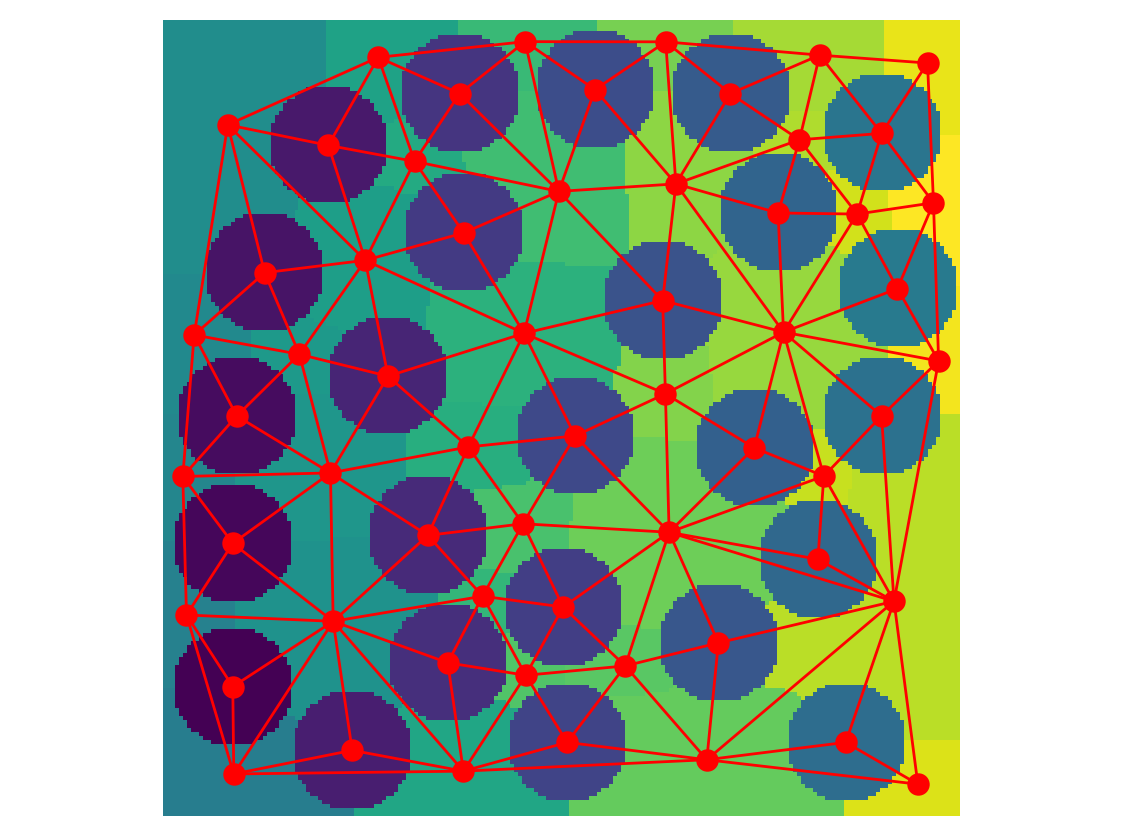

In [65]:
# create and plot dual network: it takes both solids phases and pore phases as part of the network 
pn2 = op.io.network_from_porespy(net2.network)

ax = op.visualization.plot_connections(pn2, c='r')
ax = op.visualization.plot_coordinates(pn2, c='r',markersize=50, ax=ax)
fig, ax = plt.gcf(), plt.gca()
ax.imshow(net2.regions.T)
ax.axis(False);


The above shows the additional network comprised of the solids (although they don’t actually connect in this 2D example) as well as the void-solid connections. We can improve this plot by coloring the different types of pores and throats differently. If we print pn2 we can see that snow2 has created some labels for us, by assuming phase names of “phase1” and “phase2”.

In [63]:
print(pn2)


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Network at 0x19756707e30>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  throat.conns                                                    161 / 161
  3  pore.coords                                                       60 / 60
  4  pore.region_label                                                 60 / 60
  5  pore.phase                                                        60 / 60
  6  throat.phases                                                   161 / 161
  7  pore.region_volume                                                60 / 60
  8  pore.equivalent_diameter                                          60 / 60
  9  pore.local_peak                                                   60 / 60
 1

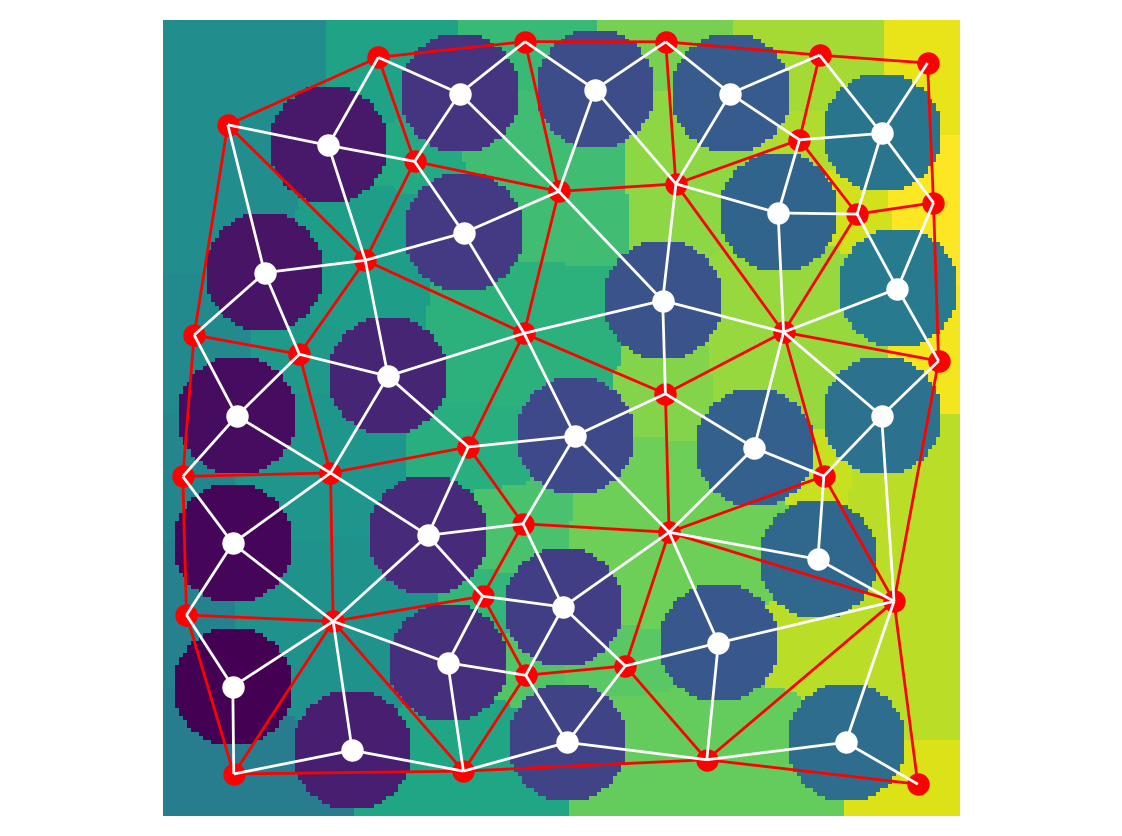

In [70]:
# The original pore space (now phase 1) network is in red.
# The grain space network and its connections - only to pore space, as the grains are actually disconnected in this exercise, is in white.

ax = op.visualization.plot_connections(pn2, throats=pn2['throat.phase2_phase2'], c='r')
ax = op.visualization.plot_connections(pn2, throats=pn2['throat.phase2_phase1'], c='w', ax=ax)
ax = op.visualization.plot_coordinates(pn2, pores=pn2['pore.phase2'], c='r', markersize=50, ax=ax)
ax = op.visualization.plot_coordinates(pn2, pores=pn2['pore.phase1'], c='w', markersize=50, ax=ax)
fig, ax = plt.gcf(), plt.gca()
ax.imshow(net2.regions.T)
ax.axis(False);

## Read Berea-like micromodel data

Berea micromodel data in this directory modified from: Yashar Mehmani, and Hamdi Tchelepi. PNM vs. DNS Intercomparison Dataset for Transport in Micromodels. Digital Rocks Portal (January 2017). http://www.digitalrocksportal.org/projects/79


We will first create the network for the pore space.
__Play with sigma__ to get the influence of oversegmentation: with sigma = 0, no peaks are filtered, and with sigma = 1.0 they are filtered to a reasonable number.

In [84]:
import numpy as np

# change the name of the file as desired
# There are two options - Berea200.txt and Berea500.txt. They are both representing the same micromodel, but are acting as two different resolutions.
# for the exercise below, 200 by 200 is easier to work with and see differences.
filename = 'Berea200.txt'
N = 200 #linear size, 200 or 500

def read_text_file(filename,datatype):
    test=open(filename, 'r')
    data=np.fromfile(test,dtype=datatype,count=-1,sep=" ")
    test.close()
    return data

     
berea = read_text_file(filename,'float')
data=np.transpose(berea).reshape(N,N)


We will first create the network for the pore space. Play with sigma to get the influence of oversegmentation: with sigma = 0, no peaks are filtered, and with sigma = 1.0 they are filtered to a reasonable number.


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Network at 0x1976013a670>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  throat.conns                                                    214 / 214
  3  pore.coords                                                     198 / 198
  4  pore.region_label                                               198 / 198
  5  pore.phase                                                      198 / 198
  6  throat.phases                                                   214 / 214
  7  pore.region_volume                                              198 / 198
  8  pore.equivalent_diameter                                        198 / 198
  9  pore.local_peak                                                 198 / 198
 1

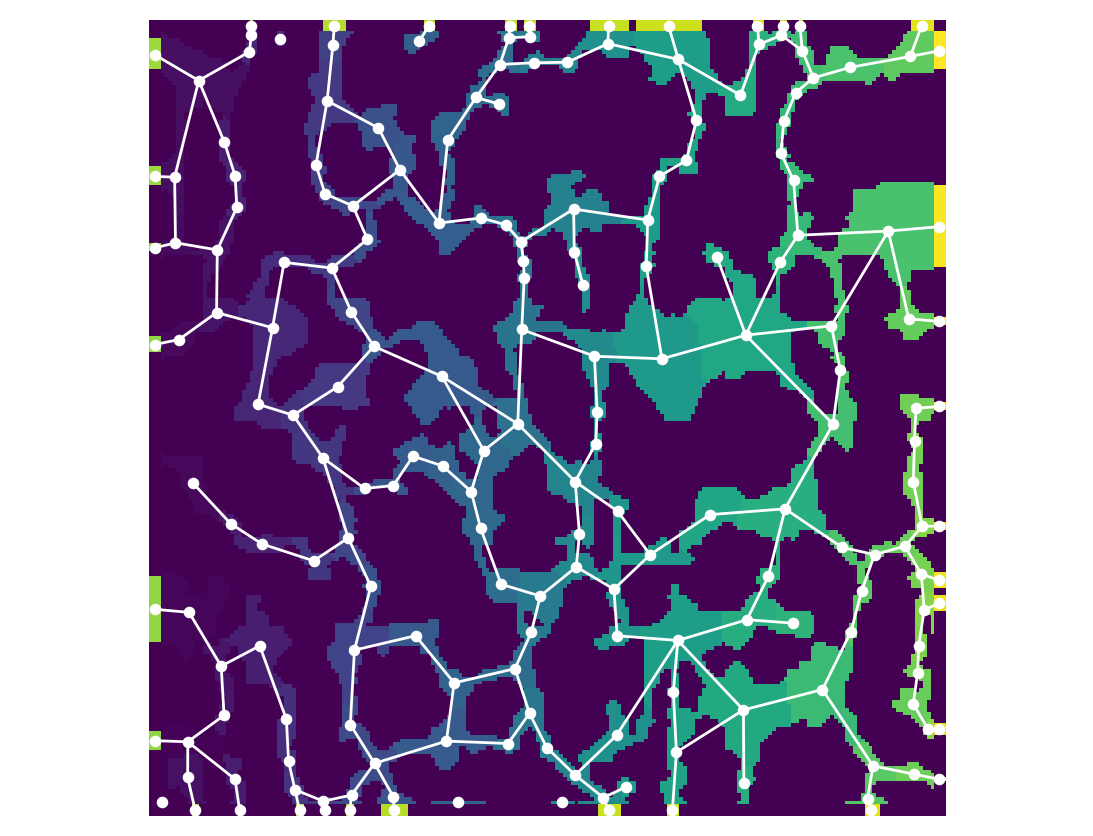

In [87]:
import porespy as ps
import openpnm as op

import matplotlib.cm as cm
import matplotlib.pyplot as plt
ps.visualization.set_mpl_style()
np.random.seed(1)

# this algorithm requires uint data
data = np.uint8(data)
type(data[0,0])

# Play with sigma to get the influence of oversegmentation: with sigma = 0, not peaks are filtered, and with sigma = 1.0 they are filtered to a reasonable number.
snow_out = ps.networks.snow2(data, sigma = 1.0, voxel_size=1)

pn = op.io.network_from_porespy(snow_out.network)
print(pn)

ax = op.visualization.plot_connections(pn, c='w')
ax = op.visualization.plot_coordinates(pn, markersize=10, c = 'w', ax=ax)
fig, ax = plt.gcf(), plt.gca()
ax.imshow(snow_out.regions.T)
ax.axis(False);


Assignment
- Copy the steps of the disk exercise above that create network for both solid and void space.
- Use __phase_alias__ to name networks 'solid' and 'void' (of whatever other networks you please)

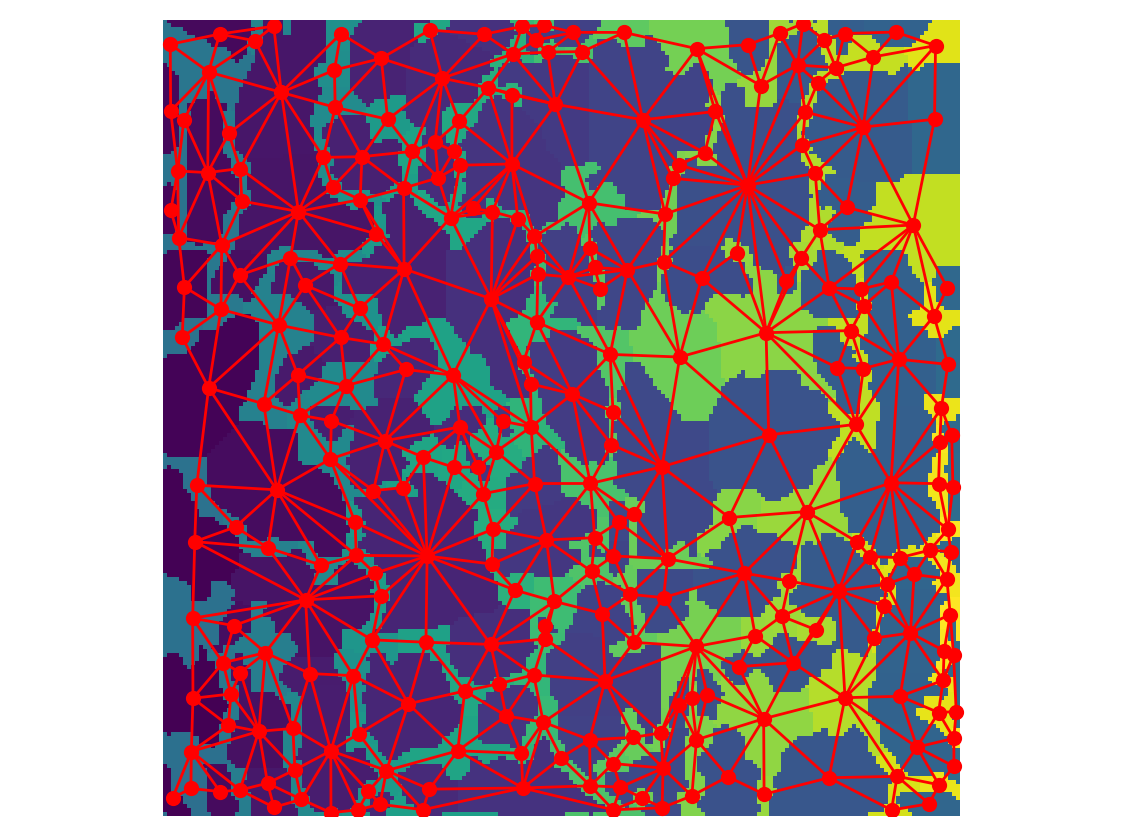

In [93]:
# dual network extraction from an image of 1s and 2s
snow_out2 = ps.networks.snow2(phases=data.astype(int) + 1, boundary_width=0)
pnet2 = op.io.network_from_porespy(snow_out2.network)
ax = op.visualization.plot_connections(pnet2, c='r')
ax = op.visualization.plot_coordinates(pnet2, c='r',markersize=20, ax=ax)
fig, ax = plt.gcf(), plt.gca()
ax.imshow(snow_out2.regions.T)
ax.axis(False);


In [94]:
print(pnet2)


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Network at 0x19762d19b80>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  throat.conns                                                    791 / 791
  3  pore.coords                                                     289 / 289
  4  pore.region_label                                               289 / 289
  5  pore.phase                                                      289 / 289
  6  throat.phases                                                   791 / 791
  7  pore.region_volume                                              289 / 289
  8  pore.equivalent_diameter                                        289 / 289
  9  pore.local_peak                                                 289 / 289
 1

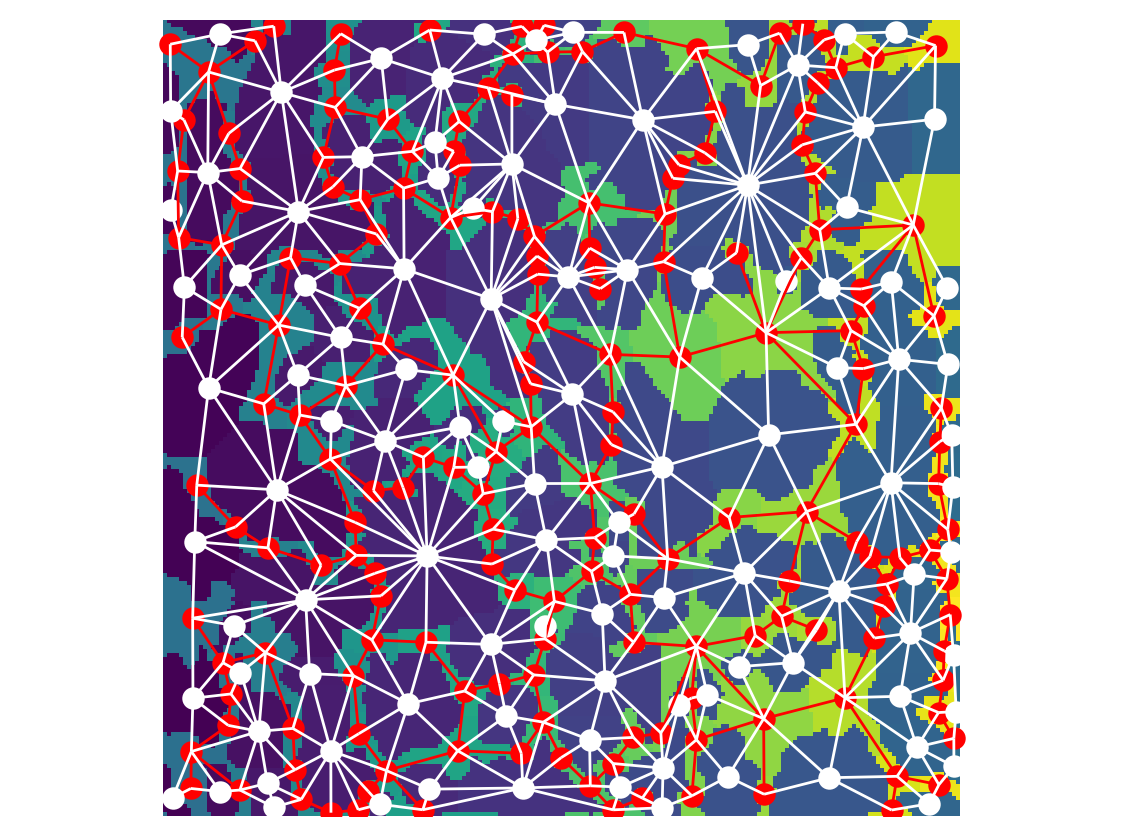

In [98]:
# The original pore space (now phase 1) network is in red.
# The grain space network and its connections - only to pore space, as the grains are actually disconnected in this exercise, is in white.

ax = op.visualization.plot_connections(pnet2, throats=pnet2['throat.phase2_phase2'], c='r')
ax = op.visualization.plot_connections(pnet2, throats=pnet2['throat.phase2_phase1'], c='w', ax=ax)
ax = op.visualization.plot_connections(pnet2, throats=pnet2['throat.phase1_phase1'], c='w', ax=ax)
ax = op.visualization.plot_coordinates(pnet2, pores=pnet2['pore.phase2'], c='r', markersize=50, ax=ax)
ax = op.visualization.plot_coordinates(pnet2, pores=pnet2['pore.phase1'], c='w', markersize=50, ax=ax)
fig, ax = plt.gcf(), plt.gca()
ax.imshow(snow_out2.regions.T)
ax.axis(False);